## Energetic Consumption

In [1]:
# Initialisation des bibliothèques et des composants utilitaires de l'analyse.
import io
from pathlib import Path

import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from energy_sights.config import RAW_DATA_DIR, critical_features, target, INTERIM_DATA_DIR, PROCESSED_DATA_DIR
from energy_sights.features import engineer_features
from energy_sights.logging_config import setup_logging
from energy_sights.preprocessing import nan_percent, drop_constant_columns, clean_neighborhood, \
    find_case_insensitive_duplicates, numeric_describe, logarithm
from energy_sights.plots import plot_distribution, interactive_distribution, heat_correlation

2026-02-16 00:36:35.035 | INFO     | energy_sights.config:<module>:11 - PROJ_ROOT path is: C:\ML_projects\energy_sights


2026-02-16 00:36:35 | INFO     | energy_sights.preprocessing - Starting the Preprocessing
2026-02-16 00:36:35.074 | INFO     | energy_sights.preprocessing:<module>:12 - Starting the Preprocessing
2026-02-16 00:36:35 | SUCCESS  | energy_sights.preprocessing - End of the preprocessing
2026-02-16 00:36:35.079 | SUCCESS  | energy_sights.preprocessing:<module>:90 - End of the preprocessing


In [2]:
import importlib
import energy_sights.plots

In [3]:
importlib.reload(energy_sights.plots)
importlib.reload(energy_sights.features)

<module 'energy_sights.features' from 'C:\\ML_projects\\energy_sights\\energy_sights\\features.py'>

In [4]:
setup_logging()

In [5]:
# Paramétrage global des visualisations.
sns.set_style(style='darkgrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 13
plt.rcParams['font.weight'] = 'bold'

# Configuration des axes des graphiques.
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'

In [6]:
datafile_path = RAW_DATA_DIR / '2016_Building_Energy_Benchmarking.csv'

In [7]:
# noinspection PyArgumentList
df = pd.read_csv(filepath_or_buffer=datafile_path)

In [8]:
df.head(n=5)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [9]:
df.shape

(3376, 46)

In [10]:
column_names = df.columns.tolist()

In [11]:
# Generation d'un rapport tabulaire des noms de colonnes pour revue structurelle.
buffer = io.StringIO()
df.info(memory_usage='deep', verbose=True, buf=buffer)
df_information = buffer.getvalue()
print(df_information)

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [12]:
column_names

['OSEBuildingID',
 'DataYear',
 'BuildingType',
 'PrimaryPropertyType',
 'PropertyName',
 'Address',
 'City',
 'State',
 'ZipCode',
 'TaxParcelIdentificationNumber',
 'CouncilDistrictCode',
 'Neighborhood',
 'Latitude',
 'Longitude',
 'YearBuilt',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'YearsENERGYSTARCertified',
 'ENERGYSTARScore',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'DefaultData',
 'Comments',
 'ComplianceStatus',
 'Outlier',
 'TotalGHGEmissions',
 'GHGEmissionsIntensity']

In [13]:
# Analyse des valeurs uniques de la colonne ZipCode.
df['ZipCode'].nunique()

55

In [14]:
df.nunique().rename('unique_values')

OSEBuildingID                      3376
DataYear                              1
BuildingType                          8
PrimaryPropertyType                  24
PropertyName                       3362
Address                            3354
City                                  1
State                                 1
ZipCode                              55
TaxParcelIdentificationNumber      3268
CouncilDistrictCode                   7
Neighborhood                         19
Latitude                           2876
Longitude                          2656
YearBuilt                           113
NumberofBuildings                    17
NumberofFloors                       50
PropertyGFATotal                   3195
PropertyGFAParking                  496
PropertyGFABuilding(s)             3193
ListOfAllPropertyUseTypes           466
LargestPropertyUseType               56
LargestPropertyUseTypeGFA          3122
SecondLargestPropertyUseType         50
SecondLargestPropertyUseTypeGFA    1352


In [15]:
df['Neighborhood'].unique().tolist()

['DOWNTOWN',
 'SOUTHEAST',
 'NORTHEAST',
 'EAST',
 'Central',
 'NORTH',
 'MAGNOLIA / QUEEN ANNE',
 'LAKE UNION',
 'GREATER DUWAMISH',
 'BALLARD',
 'NORTHWEST',
 'CENTRAL',
 'SOUTHWEST',
 'DELRIDGE',
 'Ballard',
 'North',
 'Delridge',
 'Northwest',
 'DELRIDGE NEIGHBORHOODS']

## **Data Cleansing**

In [16]:
# Suppression des colonnes constantes.
constant_columns = df.nunique()[df.nunique().apply(func=lambda x: x == 1)].index.tolist()

In [17]:
df.nunique().apply(func=lambda x: x == 1).rename('unique_values')

OSEBuildingID                      False
DataYear                            True
BuildingType                       False
PrimaryPropertyType                False
PropertyName                       False
Address                            False
City                                True
State                               True
ZipCode                            False
TaxParcelIdentificationNumber      False
CouncilDistrictCode                False
Neighborhood                       False
Latitude                           False
Longitude                          False
YearBuilt                          False
NumberofBuildings                  False
NumberofFloors                     False
PropertyGFATotal                   False
PropertyGFAParking                 False
PropertyGFABuilding(s)             False
ListOfAllPropertyUseTypes          False
LargestPropertyUseType             False
LargestPropertyUseTypeGFA          False
SecondLargestPropertyUseType       False
SecondLargestPro

In [18]:
constant_columns

['DataYear', 'City', 'State']

In [19]:
df.nunique()

OSEBuildingID                      3376
DataYear                              1
BuildingType                          8
PrimaryPropertyType                  24
PropertyName                       3362
Address                            3354
City                                  1
State                                 1
ZipCode                              55
TaxParcelIdentificationNumber      3268
CouncilDistrictCode                   7
Neighborhood                         19
Latitude                           2876
Longitude                          2656
YearBuilt                           113
NumberofBuildings                    17
NumberofFloors                       50
PropertyGFATotal                   3195
PropertyGFAParking                  496
PropertyGFABuilding(s)             3193
ListOfAllPropertyUseTypes           466
LargestPropertyUseType               56
LargestPropertyUseTypeGFA          3122
SecondLargestPropertyUseType         50
SecondLargestPropertyUseTypeGFA    1352


In [20]:
df['ComplianceStatus'].unique().tolist()

['Compliant', 'Error - Correct Default Data', 'Missing Data', 'Non-Compliant']

In [21]:
df['ComplianceStatus'].value_counts(normalize=False, sort=True, ascending=False, dropna=True)

ComplianceStatus
Compliant                       3211
Error - Correct Default Data     113
Non-Compliant                     37
Missing Data                      15
Name: count, dtype: int64

In [22]:
df = drop_constant_columns(df=df)

2026-02-16 00:36:59 | INFO     | energy_sights.preprocessing - The constant columns of the dataframe are: ['DataYear', 'City', 'State']
2026-02-16 00:36:59.808 | INFO     | energy_sights.preprocessing:drop_constant_columns:16 - The constant columns of the dataframe are: ['DataYear', 'City', 'State']


In [23]:
df['DefaultData'].unique().tolist()

[False, True]

In [24]:
df['DefaultData'].value_counts(normalize=True, sort=True, ascending=False, dropna=True
                               )

DefaultData
False    0.966528
True     0.033472
Name: proportion, dtype: float64

In [25]:
# Analyse exploratoire de la colonne PrimaryPropertyType.
df['PrimaryPropertyType'].unique().tolist()

['Hotel',
 'Other',
 'Mid-Rise Multifamily',
 'Mixed Use Property',
 'K-12 School',
 'University',
 'Small- and Mid-Sized Office',
 'Self-Storage Facility',
 'Warehouse',
 'Large Office',
 'Senior Care Community',
 'Medical Office',
 'Retail Store',
 'Hospital',
 'Residence Hall',
 'Distribution Center',
 'Worship Facility',
 'Low-Rise Multifamily',
 'Supermarket / Grocery Store',
 'Laboratory',
 'Refrigerated Warehouse',
 'Restaurant',
 'High-Rise Multifamily',
 'Office']

In [26]:
print(df_information)

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [27]:
df.filter(items=['PrimaryPropertyType'])

,PrimaryPropertyType
0,Hotel
1,Hotel
2,Hotel
3,Hotel
4,Hotel
...,...
3371,Office
3372,Other
3373,Other
3374,Mixed Use Property


In [28]:
# Analyse exploratoire de la colonne LargestPropertyUseType.
df['LargestPropertyUseType'].value_counts(normalize=False, ascending=False, sort=True, dropna=False)

LargestPropertyUseType
Multifamily Housing                                     1667
Office                                                   498
Non-Refrigerated Warehouse                               199
K-12 School                                              139
Other                                                    102
Retail Store                                              99
Hotel                                                     77
Worship Facility                                          71
Distribution Center                                       54
Senior Care Community                                     46
Medical Office                                            41
Supermarket/Grocery Store                                 41
Parking                                                   32
Other - Recreation                                        31
Self-Storage Facility                                     28
College/University                                        25
R

In [29]:
# Observation des valeurs uniques de cette variable.
df['LargestPropertyUseType'].nunique()

56

In [30]:
df['BuildingType'].value_counts(normalize=False, sort=True, ascending=False, dropna=False)

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

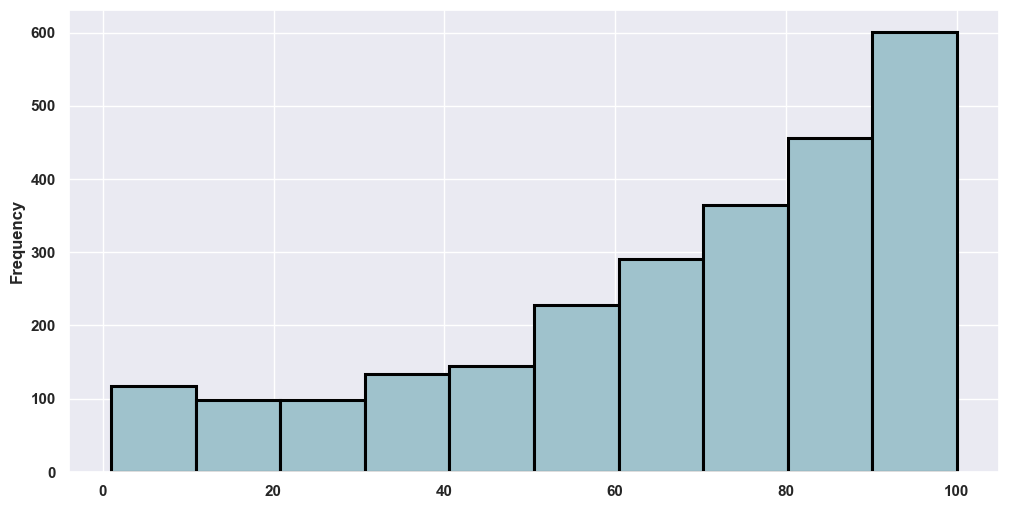

In [31]:
df['ENERGYSTARScore'].plot(kind='hist', ec='k', color='#9FC2CC', lw=2.2)

In [32]:
print(df_information)

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [33]:
# Analyse de la colonne NumberofBuildings.
df['NumberofBuildings'].value_counts(normalize=False, dropna=False, sort=True, ascending=True)

NumberofBuildings
27.0        1
11.0        1
7.0         1
16.0        1
23.0        1
111.0       1
14.0        2
9.0         2
10.0        2
8.0         3
6.0         5
NaN         8
5.0        10
4.0        12
3.0        22
2.0        37
0.0        92
1.0      3175
Name: count, dtype: int64

In [34]:
df['NumberofBuildings'].nunique()
df['NumberofFloors'].nunique()

50

In [35]:
# Filtrage des donnees pour conserver les enregistrements conformes et non imputés par défaut.
df['ComplianceStatus'].value_counts(normalize=False, sort=True, ascending=False, dropna=False)

ComplianceStatus
Compliant                       3211
Error - Correct Default Data     113
Non-Compliant                     37
Missing Data                      15
Name: count, dtype: int64

In [36]:
df['DefaultData'].value_counts(normalize=False, sort=True, ascending=False, dropna=False)

DefaultData
False    3263
True      113
Name: count, dtype: int64

In [37]:
# Filtrage selon ComplianceStatus et DefaultData.
df_compliant = df.query(expr="(ComplianceStatus == 'Compliant') and (DefaultData == False)", inplace=False)

In [38]:
df_compliant.info(memory_usage='deep')

<class 'pandas.DataFrame'>
Index: 3211 entries, 0 to 3375
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3211 non-null   int64  
 1   BuildingType                     3211 non-null   str    
 2   PrimaryPropertyType              3211 non-null   str    
 3   PropertyName                     3211 non-null   str    
 4   Address                          3211 non-null   str    
 5   ZipCode                          3198 non-null   float64
 6   TaxParcelIdentificationNumber    3211 non-null   str    
 7   CouncilDistrictCode              3211 non-null   int64  
 8   Neighborhood                     3211 non-null   str    
 9   Latitude                         3211 non-null   float64
 10  Longitude                        3211 non-null   float64
 11  YearBuilt                        3211 non-null   int64  
 12  NumberofBuildings                320

In [39]:
df_compliant.shape

(3211, 43)

## PropertyGFAParking

In [40]:
# Verification des donnees de la colonne PropertyGFAParking.
df_compliant['PropertyGFAParking'].head()

0         0
1     15064
2    196718
3         0
4     62000
Name: PropertyGFAParking, dtype: int64

In [41]:
numeric_describe(df=df_compliant, col='PropertyGFAParking').to_dict()

{'count': 3211.0,
 'mean': 8363.015882902522,
 'std': 33090.18405035005,
 'min': 0.0,
 '25%': 0.0,
 '50%': 0.0,
 '75%': 0.0,
 'max': 512608.0,
 'mode': 0.0}

In [42]:
interactive_distribution(df=df_compliant, col='PropertyGFAParking')

### Because of all the information we get from this feature, we'll use it finally for the training of the model

## I think we'll continue all the work with the compliant buildings to ensure the quality of the prediction

In [43]:
column_names

['OSEBuildingID',
 'DataYear',
 'BuildingType',
 'PrimaryPropertyType',
 'PropertyName',
 'Address',
 'City',
 'State',
 'ZipCode',
 'TaxParcelIdentificationNumber',
 'CouncilDistrictCode',
 'Neighborhood',
 'Latitude',
 'Longitude',
 'YearBuilt',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'YearsENERGYSTARCertified',
 'ENERGYSTARScore',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'DefaultData',
 'Comments',
 'ComplianceStatus',
 'Outlier',
 'TotalGHGEmissions',
 'GHGEmissionsIntensity']

In [44]:
critical_features

['PrimaryPropertyType',
 'YearBuilt',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'Neighborhood',
 'NumberofBuildings',
 'NumberofFloors',
 'BuildingType',
 'Latitude',
 'Longitude']

In [45]:
# Selection des variables explicatives et des cibles de prediction énergétique.
df_compliant_filtered = df_compliant.filter(items=critical_features + target)

In [46]:
df_compliant_filtered.head(n=5)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions
0,Hotel,1927,88434,0,DOWNTOWN,1.0,12,NonResidential,47.61220,-122.33799,7226362.5,249.98
1,Hotel,1996,103566,15064,DOWNTOWN,1.0,11,NonResidential,47.61317,-122.33393,8387933.0,295.86
2,Hotel,1969,956110,196718,DOWNTOWN,1.0,41,NonResidential,47.61393,-122.33810,72587024.0,2089.28
3,Hotel,1926,61320,0,DOWNTOWN,1.0,10,NonResidential,47.61412,-122.33664,6794584.0,286.43
4,Hotel,1980,175580,62000,DOWNTOWN,1.0,18,NonResidential,47.61375,-122.34047,14172606.0,505.01


In [47]:
# Analyse de la variable PrimaryPropertyType.
df_compliant_filtered.nunique()

PrimaryPropertyType      23
YearBuilt               113
PropertyGFATotal       3041
PropertyGFAParking      485
Neighborhood             19
NumberofBuildings        17
NumberofFloors           50
BuildingType              8
Latitude               2744
Longitude              2536
SiteEnergyUse(kBtu)    3211
TotalGHGEmissions      2700
dtype: int64

In [48]:
# Verification de la structure du DataFrame filtre.
buffer = io.StringIO()
df_compliant_filtered.info(memory_usage='deep', buf=buffer)
final_information = buffer.getvalue()
print(final_information)

<class 'pandas.DataFrame'>
Index: 3211 entries, 0 to 3375
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PrimaryPropertyType  3211 non-null   str    
 1   YearBuilt            3211 non-null   int64  
 2   PropertyGFATotal     3211 non-null   int64  
 3   PropertyGFAParking   3211 non-null   int64  
 4   Neighborhood         3211 non-null   str    
 5   NumberofBuildings    3208 non-null   float64
 6   NumberofFloors       3211 non-null   int64  
 7   BuildingType         3211 non-null   str    
 8   Latitude             3211 non-null   float64
 9   Longitude            3211 non-null   float64
 10  SiteEnergyUse(kBtu)  3211 non-null   float64
 11  TotalGHGEmissions    3207 non-null   float64
dtypes: float64(5), int64(4), str(3)
memory usage: 851.9 KB



In [49]:
nan_percent(df=df_compliant_filtered)

PrimaryPropertyType ->  0.0000 %

YearBuilt ->  0.0000 %

PropertyGFATotal ->  0.0000 %

PropertyGFAParking ->  0.0000 %

Neighborhood ->  0.0000 %

NumberofBuildings ->  0.0009 %

NumberofFloors ->  0.0000 %

BuildingType ->  0.0000 %

Latitude ->  0.0000 %

Longitude ->  0.0000 %

SiteEnergyUse(kBtu) ->  0.0000 %

TotalGHGEmissions ->  0.0012 %



In [50]:
df_compliant_filtered[df_compliant_filtered['TotalGHGEmissions'].isna()].filter(items=['NumberofBuildings', 'TotalGHGEmissions'])

,NumberofBuildings,TotalGHGEmissions
1768,NaN,NaN
2321,NaN,NaN
2480,NaN,NaN
3348,1.0,NaN


In [51]:
df_compliant_filtered[df_compliant_filtered['TotalGHGEmissions'].isnull()]

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions
1768,Low-Rise Multifamily,1992,29357,0,SOUTHWEST,NaN,4,Multifamily LR (1-4),47.54731,-122.38656,5.636832e+05,NaN
2321,Low-Rise Multifamily,1963,28472,0,NORTHEAST,NaN,4,Multifamily LR (1-4),47.67025,-122.31232,7.702755e+05,NaN
2480,Low-Rise Multifamily,1969,30420,0,SOUTHWEST,NaN,3,Multifamily LR (1-4),47.58968,-122.38587,1.049639e+06,NaN
3348,Low-Rise Multifamily,2015,36685,8254,EAST,1.0,4,Multifamily LR (1-4),47.62441,-122.31300,8.202201e+05,NaN


In [52]:
# Identification des bâtiments avec valeurs manquantes dans TotalGHGEmissions.
df_compliant[df_compliant['TotalGHGEmissions'].isna()]

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
1768,23355,Multifamily LR (1-4),Low-Rise Multifamily,GRAHAM VIEW,6040 CALIFORNIA AVE SW,98136.0,7625703280,1,SOUTHWEST,47.54731,...,NaN,NaN,NaN,NaN,False,NaN,Compliant,NaN,NaN,NaN
2321,25431,Multifamily LR (1-4),Low-Rise Multifamily,PONDERAY APTS,5625 15TH AVE NE,98105.0,5226300030,4,NORTHEAST,47.67025,...,NaN,NaN,NaN,NaN,False,NaN,Compliant,NaN,NaN,NaN
2480,25763,Multifamily LR (1-4),Low-Rise Multifamily,Villa Andora,1520 CALIFORNIA AVE SW,98116.0,9272201340,1,SOUTHWEST,47.58968,...,NaN,NaN,NaN,NaN,False,NaN,Compliant,NaN,NaN,NaN
3348,50082,Multifamily LR (1-4),Low-Rise Multifamily,STREAM FIFTEEN,605 15TH AVE E,98112.0,3303700030,3,EAST,47.62441,...,NaN,NaN,NaN,NaN,False,NaN,Compliant,NaN,NaN,NaN


In [53]:
# Verification des valeurs manquantes de NumberofBuildings.
df_compliant_filtered[df_compliant_filtered['NumberofBuildings'].isna()]

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions
1768,Low-Rise Multifamily,1992,29357,0,SOUTHWEST,NaN,4,Multifamily LR (1-4),47.54731,-122.38656,5.636832e+05,NaN
2321,Low-Rise Multifamily,1963,28472,0,NORTHEAST,NaN,4,Multifamily LR (1-4),47.67025,-122.31232,7.702755e+05,NaN
2480,Low-Rise Multifamily,1969,30420,0,SOUTHWEST,NaN,3,Multifamily LR (1-4),47.58968,-122.38587,1.049639e+06,NaN


In [54]:
# Suppression des lignes manquantes afin d'éviter une imputation artificielle.
# Compte tenu de la repartition des valeurs manquantes, suppression des observations concernées.
# TotalGHGEmissions
df_compliant_filtered = df_compliant_filtered.dropna(axis=0, subset='TotalGHGEmissions', inplace=False, ignore_index=False, how='any')

In [55]:
# Verification de la coherence des transformations effectuées.
nan_percent(df=df_compliant_filtered)

PrimaryPropertyType ->  0.0000 %

YearBuilt ->  0.0000 %

PropertyGFATotal ->  0.0000 %

PropertyGFAParking ->  0.0000 %

Neighborhood ->  0.0000 %

NumberofBuildings ->  0.0000 %

NumberofFloors ->  0.0000 %

BuildingType ->  0.0000 %

Latitude ->  0.0000 %

Longitude ->  0.0000 %

SiteEnergyUse(kBtu) ->  0.0000 %

TotalGHGEmissions ->  0.0000 %



In [56]:
df_compliant_filtered.head(n=5)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions
0,Hotel,1927,88434,0,DOWNTOWN,1.0,12,NonResidential,47.61220,-122.33799,7226362.5,249.98
1,Hotel,1996,103566,15064,DOWNTOWN,1.0,11,NonResidential,47.61317,-122.33393,8387933.0,295.86
2,Hotel,1969,956110,196718,DOWNTOWN,1.0,41,NonResidential,47.61393,-122.33810,72587024.0,2089.28
3,Hotel,1926,61320,0,DOWNTOWN,1.0,10,NonResidential,47.61412,-122.33664,6794584.0,286.43
4,Hotel,1980,175580,62000,DOWNTOWN,1.0,18,NonResidential,47.61375,-122.34047,14172606.0,505.01


In [57]:
df_compliant_filtered.describe(include='all')

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions
count,3207,3207.000000,3.207000e+03,3207.000000,3207,3207.000000,3207.000000,3207,3207.000000,3207.000000,3.207000e+03,3207.000000
unique,23,NaN,NaN,NaN,19,NaN,NaN,8,NaN,NaN,NaN,NaN
top,Low-Rise Multifamily,NaN,NaN,NaN,DOWNTOWN,NaN,NaN,NonResidential,NaN,NaN,NaN,NaN
freq,952,NaN,NaN,NaN,556,NaN,NaN,1432,NaN,NaN,NaN,NaN
mean,NaN,1968.719676,9.587476e+04,8370.873090,NaN,1.111007,4.806049,NaN,47.624565,-122.335118,5.539669e+06,122.211886
std,NaN,33.171462,2.229174e+05,33109.830984,NaN,2.159319,5.594795,NaN,0.047003,0.026554,2.212364e+07,551.534876
min,NaN,1900.000000,1.128500e+04,0.000000,NaN,0.000000,0.000000,NaN,47.502240,-122.414250,5.713320e+04,-0.800000
25%,NaN,1948.000000,2.829350e+04,0.000000,NaN,1.000000,2.000000,NaN,47.601055,-122.350350,9.387549e+05,9.640000
50%,NaN,1975.000000,4.387800e+04,0.000000,NaN,1.000000,4.000000,NaN,47.618910,-122.332630,1.809587e+06,33.920000
75%,NaN,1997.000000,9.158000e+04,0.000000,NaN,1.000000,5.000000,NaN,47.656745,-122.320215,4.277747e+06,94.385000


In [58]:
# Export du jeu intermédiaire dans le repertoire data/interim.
df_compliant_filtered.to_csv(path_or_buf=INTERIM_DATA_DIR / 'df_compliant_filtered.csv', index=False)

## Comparison of the columns PrimaryPropertyType and BuildingType

In [59]:
df_compliant_filtered['PrimaryPropertyType'].value_counts(normalize=False, ascending=False, sort=True, dropna=False)

PrimaryPropertyType
Low-Rise Multifamily           952
Mid-Rise Multifamily           553
Small- and Mid-Sized Office    287
Other                          250
Warehouse                      185
Large Office                   169
Mixed Use Property             132
High-Rise Multifamily          103
Retail Store                    85
Hotel                           76
Worship Facility                69
Distribution Center             53
K-12 School                     50
Senior Care Community           44
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      25
Residence Hall                  23
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Name: count, dtype: int64

In [60]:
df_compliant_filtered['BuildingType'].value_counts(normalize=False, sort=True, ascending=True, dropna=True)

BuildingType
Nonresidential WA          1
SPS-District K-12         10
Campus                    24
Nonresidential COS        81
Multifamily HR (10+)     108
Multifamily MR (5-9)     570
Multifamily LR (1-4)     981
NonResidential          1432
Name: count, dtype: int64

In [61]:
building_type: list[str] = sorted(df_compliant_filtered['BuildingType'].unique().tolist(), reverse=False)

In [62]:
building_type

['Campus',
 'Multifamily HR (10+)',
 'Multifamily LR (1-4)',
 'Multifamily MR (5-9)',
 'NonResidential',
 'Nonresidential COS',
 'Nonresidential WA',
 'SPS-District K-12']

In [63]:
residential_buildings = building_type[1:4]

In [64]:
residential_buildings

['Multifamily HR (10+)', 'Multifamily LR (1-4)', 'Multifamily MR (5-9)']

In [65]:
# Filtrage des categories pour conserver uniquement les bâtiments non résidentiels.
df_compliant_filtered = df_compliant_filtered.query(expr="BuildingType not in @residential_buildings")

In [66]:
# Verification de la dimension du DataFrame.
df_compliant_filtered.shape

(1548, 12)

In [67]:
# Contrôle des categories uniques de la variable.
df_compliant_filtered['BuildingType'].unique().tolist()

['NonResidential',
 'Nonresidential COS',
 'Campus',
 'SPS-District K-12',
 'Nonresidential WA']

In [68]:
# Analyse croisée des categories avec pd.crosstab.
pd.crosstab(columns=df_compliant_filtered['BuildingType'], index=df_compliant_filtered['PrimaryPropertyType'], dropna=True, values=None,
            margins=True, margins_name='Total')

BuildingType,Campus,NonResidential,Nonresidential COS,Nonresidential WA,SPS-District K-12,Total
PrimaryPropertyType,,,,,,
Distribution Center,0,51,2,0,0,53
Hospital,0,10,0,0,0,10
Hotel,0,75,0,0,0,75
K-12 School,4,38,0,0,8,50
Laboratory,0,10,0,0,0,10
Large Office,1,164,4,0,0,169
Low-Rise Multifamily,1,1,0,0,0,2
Medical Office,0,38,1,0,0,39
Mixed Use Property,4,101,8,0,0,113


In [69]:
# Verification spécifique de la catégorie NonResidential WA.
df_compliant_filtered[df_compliant_filtered['BuildingType'] == 'Nonresidential WA']

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions
3359,University,1962,68072,0,NORTHEAST,1.0,1,Nonresidential WA,47.66127,-122.31256,3180819.25,22.17


In [70]:
# Identification du bâtiment associe a cette observation.
df_compliant[df_compliant['BuildingType'] == 'Nonresidential WA']

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
3359,50101,Nonresidential WA,University,Burke Museum,4331 Memorial Way NE,98195.0,1625049001,4,NORTHEAST,47.66127,...,932244.6875,3180819.0,0.0,0.0,False,NaN,Compliant,NaN,22.17,0.33


In [71]:
df_compliant_filtered['BuildingType'].value_counts(normalize=True, sort=True, ascending=False)

BuildingType
NonResidential        0.925065
Nonresidential COS    0.052326
Campus                0.015504
SPS-District K-12     0.006460
Nonresidential WA     0.000646
Name: proportion, dtype: float64

### Because of the weak variance in this column, I'll remove it because it will introduce bias in the model
### Also, this column don't add meaningful information, because already know we are studying non-residential buildings

In [72]:
# Suppression de cette colonne.
df_compliant_filtered = df_compliant_filtered.drop(columns='BuildingType')

In [73]:
# Analyse complémentaire de la colonne PrimaryPropertyType.
df_compliant_filtered['PrimaryPropertyType'].value_counts(normalize=False, sort=True, ascending=False)

PrimaryPropertyType
Small- and Mid-Sized Office    286
Other                          245
Warehouse                      185
Large Office                   169
Mixed Use Property             113
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             53
K-12 School                     50
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      24
Residence Hall                  21
Senior Care Community           20
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Low-Rise Multifamily             2
Name: count, dtype: int64

### Our predictions are focus on the non-residential buildings but Low_Rise Multifamily is a Residential one
### so let's drop this category

In [74]:
df_compliant_filtered = df_compliant_filtered.loc[(df_compliant_filtered['PrimaryPropertyType'] != "Low-Rise Multifamily"), :]

In [75]:
df_compliant_filtered['PrimaryPropertyType'].value_counts(normalize=False, sort=True, ascending=False, dropna=True)

PrimaryPropertyType
Small- and Mid-Sized Office    286
Other                          245
Warehouse                      185
Large Office                   169
Mixed Use Property             113
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             53
K-12 School                     50
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      24
Residence Hall                  21
Senior Care Community           20
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Name: count, dtype: int64

### Replacement of the small categories with the biggest and higher semantically and related fields

#### We will put the category Restaurant in the category Retail Store because those activities is quietly similar

In [76]:
# Regroupement des categories rares vers des categories sémantiquement proches pour limiter le sur apprentissage.
# Reduction du risque de sur apprentissage.
df_compliant_filtered['PrimaryPropertyType'] = df_compliant_filtered['PrimaryPropertyType'].replace(to_replace={
    'Refrigerated Warehouse': 'Warehouse',
    'Hospital': 'Medical Office',
    'Laboratory': 'Medical Office',
    'Restaurant': 'Retail Store'
})

## Neighborhood

In [77]:
df_compliant_filtered['Neighborhood'].value_counts(normalize=False, sort=True, ascending=False, dropna=True)

Neighborhood
DOWNTOWN                  350
GREATER DUWAMISH          328
MAGNOLIA / QUEEN ANNE     144
LAKE UNION                142
NORTHEAST                 117
EAST                      116
NORTHWEST                  74
BALLARD                    58
NORTH                      51
CENTRAL                    42
DELRIDGE                   36
SOUTHWEST                  31
SOUTHEAST                  31
North                       8
Ballard                     5
Delridge                    4
Northwest                   4
Central                     4
DELRIDGE NEIGHBORHOODS      1
Name: count, dtype: int64

In [78]:
df_compliant_filtered['Neighborhood'].unique().tolist()

['DOWNTOWN',
 'NORTHEAST',
 'EAST',
 'LAKE UNION',
 'GREATER DUWAMISH',
 'MAGNOLIA / QUEEN ANNE',
 'BALLARD',
 'NORTHWEST',
 'CENTRAL',
 'SOUTHWEST',
 'SOUTHEAST',
 'DELRIDGE',
 'NORTH',
 'North',
 'Delridge',
 'Ballard',
 'Northwest',
 'Central',
 'DELRIDGE NEIGHBORHOODS']

In [79]:
# Comptage manuel des occurrences par quartier pour contrôler la granularité des categories.
count: dict[str, int] = {}
for val in df_compliant_filtered['Neighborhood'].unique().tolist():
    if val.lower() not in count.keys():
        count[val.lower()] = 1
    else:
        count[val.lower()] += 1

duplicated_values: dict[str, int] = {k:v for k, v in count.items() if v > 1}

In [80]:
find_case_insensitive_duplicates(df=df_compliant_filtered, col='Neighborhood')

2026-02-16 00:37:35 | INFO     | energy_sights.preprocessing - Found 5 case-insensitive duplicates in 'Neighborhood'.
2026-02-16 00:37:35.703 | INFO     | energy_sights.preprocessing:find_case_insensitive_duplicates:59 - Found 5 case-insensitive duplicates in 'Neighborhood'.


{'ballard': 2, 'central': 2, 'delridge': 2, 'north': 2, 'northwest': 2}

In [81]:
# Nettoyage de la colonne Neighborhood.
df_compliant_filtered = clean_neighborhood(df=df_compliant_filtered)

In [82]:
df_compliant_filtered['Neighborhood'].unique().tolist()

['Downtown',
 'Northeast',
 'East',
 'Lake Union',
 'Greater Duwamish',
 'Magnolia / Queen Anne',
 'Ballard',
 'Northwest',
 'Central',
 'Southwest',
 'Southeast',
 'Delridge Neighborhoods',
 'North']

In [83]:
# Verification de la qualité du nettoyage.
find_case_insensitive_duplicates(df=df_compliant_filtered, col='Neighborhood')

{}

In [84]:
df_compliant_filtered.Neighborhood.nunique()

13

In [85]:
df_compliant_filtered['Neighborhood'].value_counts(normalize=False, sort=True, ascending=False
                                                   )

Neighborhood
Downtown                  350
Greater Duwamish          328
Magnolia / Queen Anne     144
Lake Union                142
Northeast                 117
East                      116
Northwest                  78
Ballard                    63
North                      59
Central                    46
Delridge Neighborhoods     41
Southwest                  31
Southeast                  31
Name: count, dtype: int64

## YearBuilt column

In [86]:
df_compliant_filtered['YearBuilt'].unique().tolist()

[1927,
 1996,
 1969,
 1926,
 1980,
 1999,
 1904,
 1998,
 1928,
 1922,
 2004,
 1930,
 1983,
 1907,
 1916,
 1985,
 2001,
 1991,
 1978,
 1906,
 1994,
 1955,
 1992,
 1961,
 1990,
 1900,
 1954,
 1911,
 1973,
 1920,
 1910,
 1982,
 1908,
 1959,
 2000,
 1997,
 1962,
 1970,
 2008,
 1965,
 1929,
 2010,
 1938,
 1986,
 2002,
 1923,
 2003,
 1941,
 2006,
 1915,
 1950,
 1958,
 2009,
 2011,
 1971,
 2007,
 1951,
 1964,
 1953,
 1937,
 1966,
 1957,
 1968,
 1924,
 2005,
 1931,
 1972,
 1952,
 1914,
 1913,
 1995,
 1981,
 1989,
 1925,
 1976,
 1909,
 1988,
 1979,
 1947,
 1984,
 1956,
 1912,
 1977,
 1960,
 1945,
 1963,
 1974,
 1975,
 1946,
 1967,
 1987,
 1949,
 1940,
 1932,
 1948,
 1993,
 1918,
 1905,
 1902,
 1921,
 1939,
 1944,
 1917,
 1942,
 1903,
 2012,
 2013,
 1919,
 1901,
 1936,
 1935,
 2014,
 2015]

In [87]:
df_compliant_filtered.YearBuilt.nunique()

113

In [88]:
df_compliant_filtered['YearBuilt'].mode().rename(index={0: 'mode1', 1: 'mode2'})

mode1    1900
Name: YearBuilt, dtype: int64

In [89]:
df_compliant_filtered['YearBuilt'].value_counts(normalize=False, dropna=True, ascending=False, sort=True)

YearBuilt
1900    43
1970    31
2000    29
1910    28
1979    28
        ..
1942     2
1901     2
1903     1
1936     1
1935     1
Name: count, Length: 113, dtype: int64

In [90]:
numeric_describe(df=df_compliant_filtered, col='YearBuilt')

count    1546.000000
mean     1961.631953
std        32.889927
min      1900.000000
25%      1930.000000
50%      1965.500000
75%      1989.000000
max      2015.000000
mode     1900.000000
Name: YearBuilt, dtype: float64

In [91]:
# Analyse des donnees selon l'année de construction (YearBuilt).
df[df['YearBuilt'] >= 2000][['PropertyName', 'PropertyGFATotal', 'NumberofFloors', 'NumberofBuildings', 'YearBuilt']]

,PropertyName,PropertyGFATotal,NumberofFloors,NumberofBuildings,YearBuilt
15,The Seattle Public Library - Central Library,412000,11,1.0,2004
23,WATERTOWN HOTEL,88592,6,1.0,2001
27,Marriott Springhill Suites (33),171866,10,1.0,2001
53,Rainier Hospitality,150453,7,1.0,2000
61,SCCA - ALLIANCE HOUSE,84103,6,1.0,2008
...,...,...,...,...,...
3358,1806,20246,4,1.0,2014
3360,Northgate Community Center,20616,1,1.0,2005
3361,Fire Station 06 (New),11685,1,1.0,2013
3362,Fire Station 35 (New),11968,1,1.0,2010


In [92]:
df[df['YearBuilt'] == df['YearBuilt'].max()][['PropertyGFATotal', 'PropertyName', 'NumberofBuildings', 'NumberofFloors', 'YearBuilt', 'SiteEnergyUse(kBtu)']]\
    .sort_values(by='SiteEnergyUse(kBtu)', ascending=False, kind='quicksort')

,PropertyGFATotal,PropertyName,NumberofBuildings,NumberofFloors,YearBuilt,SiteEnergyUse(kBtu)
3356,345290,AIBS,1.0,6,2015,3.936412e+07
3317,513816,Dexter Station,1.0,10,2015,1.876077e+07
3354,325000,Terry Hall & Maple Hall,1.0,7,2015,1.646749e+07
3333,319481,Cirrus,1.0,40,2015,1.540416e+07
3324,483397,"Sidneysea, LLC",1.0,12,2015,1.399864e+07
3323,271922,Junction 47,2.0,6,2015,7.682562e+06
3316,283479,Angeline Apartments,1.0,6,2015,6.821833e+06
3349,213952,Rooster Apartments,1.0,7,2015,6.562458e+06
3319,144614,Hilton Garden Inn Seattle,1.0,14,2015,5.525072e+06
3344,260051,Astro Apartments,1.0,7,2015,5.328224e+06


2026-02-16 00:37:40 | INFO     | energy_sights.plots - Plotting distribution for column: YearBuilt
2026-02-16 00:37:40.973 | INFO     | energy_sights.plots:plot_distribution:26 - Plotting distribution for column: YearBuilt


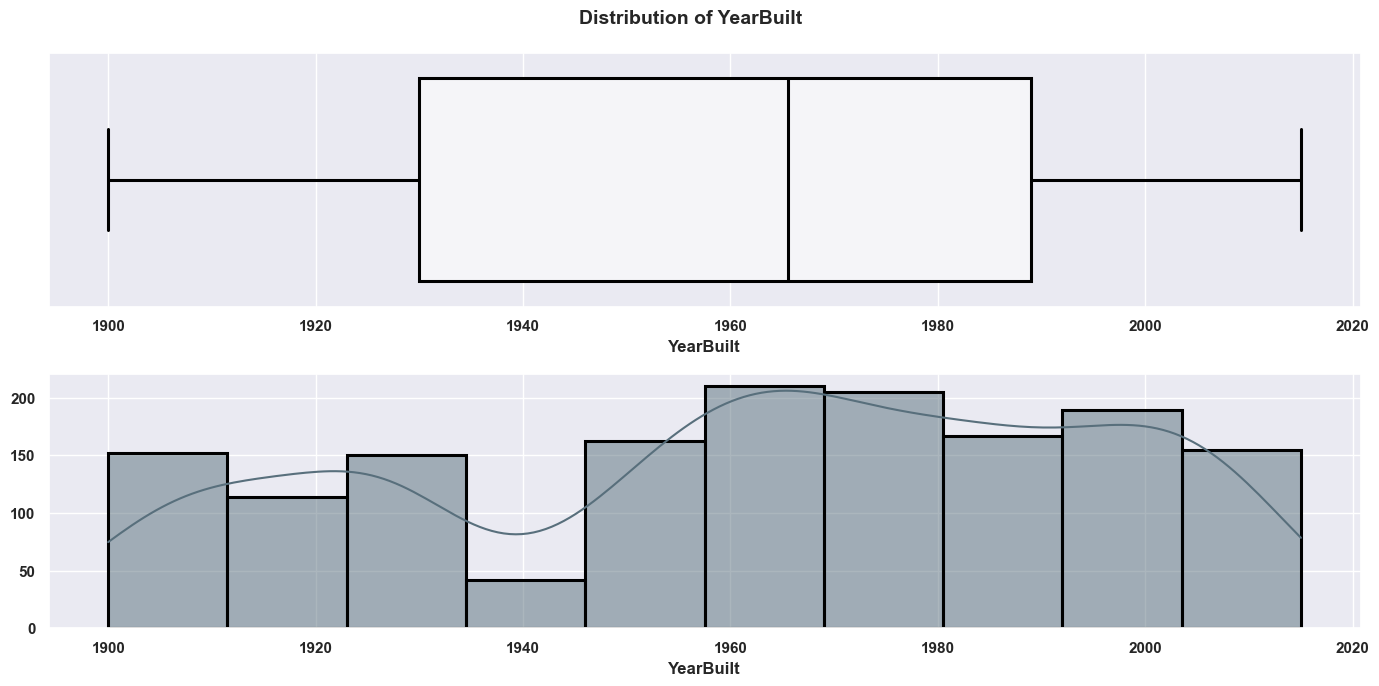

2026-02-16 00:37:41 | SUCCESS  | energy_sights.plots - Plot generation for the column YearBuilt complete
2026-02-16 00:37:41.508 | SUCCESS  | energy_sights.plots:plot_distribution:51 - Plot generation for the column YearBuilt complete


In [93]:
# Analyse de la distribution de cette colonne.
plot_distribution(df=df_compliant_filtered, col='YearBuilt')

## The NumberofBuildings column

In [94]:
df_compliant_filtered.head(n=6)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions
0,Hotel,1927,88434,0,Downtown,1.0,12,47.61220,-122.33799,7226362.5,249.98
1,Hotel,1996,103566,15064,Downtown,1.0,11,47.61317,-122.33393,8387933.0,295.86
2,Hotel,1969,956110,196718,Downtown,1.0,41,47.61393,-122.33810,72587024.0,2089.28
3,Hotel,1926,61320,0,Downtown,1.0,10,47.61412,-122.33664,6794584.0,286.43
4,Hotel,1980,175580,62000,Downtown,1.0,18,47.61375,-122.34047,14172606.0,505.01
5,Other,1999,97288,37198,Downtown,1.0,2,47.61623,-122.33657,12086616.0,301.81


In [95]:
# Statistiques descriptives de la colonne.
numeric_describe(df=df_compliant_filtered, col='NumberofBuildings')

count    1546.000000
mean        1.179172
std         3.041181
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       111.000000
mode        1.000000
Name: NumberofBuildings, dtype: float64

In [96]:
df_compliant_filtered['NumberofBuildings'].value_counts(normalize=False, sort=True, ascending=False, dropna=True)

NumberofBuildings
1.0      1442
0.0        52
2.0        14
3.0        12
5.0         7
4.0         4
6.0         4
14.0        2
8.0         2
27.0        1
11.0        1
9.0         1
7.0         1
23.0        1
10.0        1
111.0       1
Name: count, dtype: int64

In [97]:
# Filtrage des observations avec NumberofBuildings egal a 0.
df_compliant_filtered = df_compliant_filtered.query(expr="NumberofBuildings != 0", inplace=False)

In [98]:
# Verification de la nouvelle dimension du DataFrame.
df_compliant_filtered.shape

(1494, 11)

In [99]:
df_compliant_filtered['NumberofBuildings'].nunique()

15

In [100]:
df_compliant_filtered['NumberofBuildings'].value_counts(normalize=True, sort=True, ascending=False, dropna=True)

NumberofBuildings
1.0      0.965194
2.0      0.009371
3.0      0.008032
5.0      0.004685
4.0      0.002677
6.0      0.002677
14.0     0.001339
8.0      0.001339
27.0     0.000669
11.0     0.000669
9.0      0.000669
7.0      0.000669
23.0     0.000669
10.0     0.000669
111.0    0.000669
Name: proportion, dtype: float64

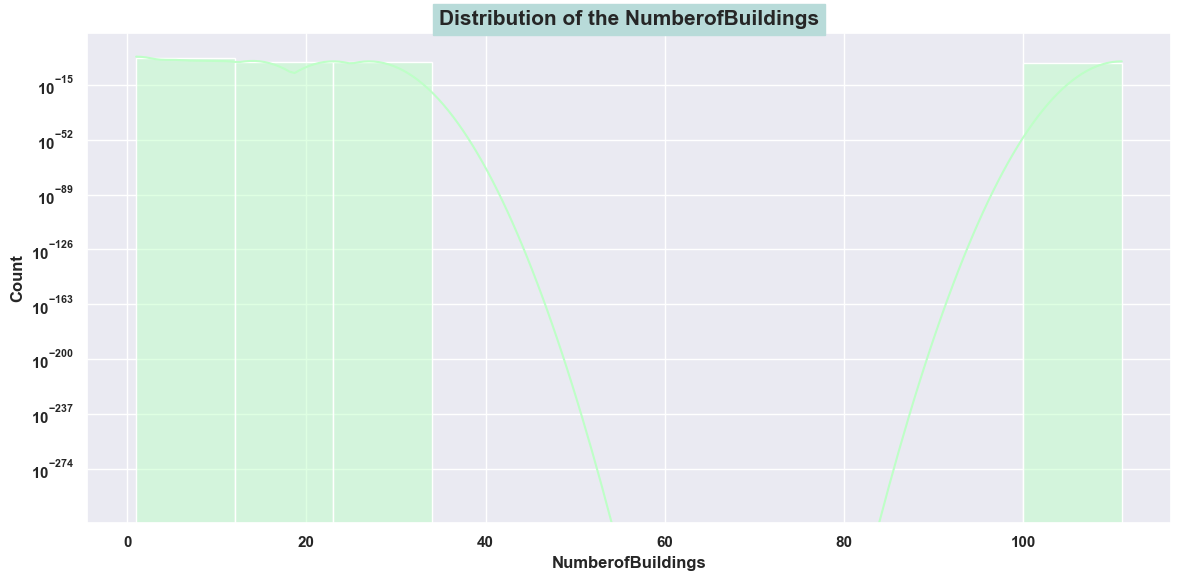

In [101]:
# Visualisation de la distribution de la variable.
fig, ax = plt.subplots(nrows=1, ncols=1)
sns.histplot(data=df_compliant_filtered,
             x='NumberofBuildings',
             element='bars',
             kde=True,
             stat='count',
             bins=10,
             ax=ax,
             color='#BEFFC7')
ax.set_title('Distribution of the NumberofBuildings', fontsize=15, fontweight='bold', backgroundcolor='#B8DBD9')
ax.set_yscale(value='log')
plt.tight_layout()
plt.show()

## Because of the skewness of this column, we'll binarize the values in two categories 0, for those which have 1 building and 1 for all the remaining

In [102]:
df_compliant_filtered['IsComplex'] = (df_compliant_filtered['NumberofBuildings'] > 1).astype(dtype=pd.Int32Dtype())

In [103]:
df_compliant_filtered['IsComplex'].value_counts(normalize=True, ascending=False, sort=True)

IsComplex
0    0.965194
1    0.034806
Name: proportion, dtype: Float64

## NumberofFloors column analysis

In [104]:
df_compliant_filtered['NumberofFloors'].nunique()

45

In [105]:
df_compliant_filtered['NumberofFloors'].mode()

0    1
Name: NumberofFloors, dtype: int64

In [106]:
# Affichage des statistiques de la colonne.
numeric_describe(df=df_compliant_filtered, col='NumberofFloors')

count    1494.000000
mean        4.293173
std         6.851970
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        99.000000
mode        1.000000
Name: NumberofFloors, dtype: float64

In [107]:
df_compliant_filtered['NumberofFloors'].value_counts(sort=True, ascending=False, normalize=False, dropna=True)

NumberofFloors
1     412
2     337
3     229
4     135
5      99
6      80
7      33
8      21
11     18
10     16
0      15
12      9
14      9
9       8
13      7
15      5
42      5
19      4
17      4
18      3
25      3
33      3
20      3
16      3
23      3
22      3
29      3
21      3
41      2
24      2
34      2
36      2
28      1
47      1
49      1
37      1
63      1
55      1
46      1
30      1
56      1
76      1
27      1
99      1
39      1
Name: count, dtype: int64

In [108]:
df[df['NumberofFloors'] == 0][['PropertyName', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PrimaryPropertyType']]

,PropertyName,NumberofBuildings,NumberofFloors,PropertyGFATotal,PrimaryPropertyType
166,Grand Hyatt Seattle,1.0,0,934292,Hotel
487,Arnold Pavilion,1.0,0,225982,Medical Office
488,2200 Westlake - SEDO,0.0,0,516407,Mixed Use Property
564,Pacific Place,1.0,0,947987,Other
1754,HART First Hill LLC,1.0,0,274568,Medical Office
1993,(ID#24086)Campus1:KC Metro Transit Atlantic Ce...,10.0,0,230971,Other
3130,Sandpoint #5,1.0,0,384772,Warehouse
3131,Sandpoint #25,1.0,0,30287,Medical Office
3132,Sandpoint #29,1.0,0,21931,Small- and Mid-Sized Office
3168,Magnuson,8.0,0,502030,Other


In [109]:
# Application d'un filtrage complémentaire sur NumberofBuildings et NumberofFloors.
df[(df['NumberofBuildings'] > 1) & (df['NumberofFloors'] != 0)][['PropertyGFATotal', 'PropertyName', 'PrimaryPropertyType', 'NumberofBuildings', 'NumberofFloors']]

,PropertyGFATotal,PropertyName,PrimaryPropertyType,NumberofBuildings,NumberofFloors
36,714095,Seattle 11-13,Warehouse,3.0,2
80,50017,UNIVERSITY INN,Hotel,2.0,4
98,285333,Swedish Ballard,Hospital,4.0,5
105,441071,SSCC MAIN CAMPUS,University,27.0,2
117,250981,Youth Services Center,Other,3.0,6
...,...,...,...,...,...
3288,83296,Belroy Apartments Modern,Mid-Rise Multifamily,3.0,6
3299,42905,129610 - Identity Seattle Building I,Mid-Rise Multifamily,2.0,7
3323,271922,Junction 47,Mid-Rise Multifamily,2.0,6
3326,318835,Odin,Mid-Rise Multifamily,2.0,7


In [110]:
# Extraction des bâtiments élevés à bâtiment unique pour auditer les anomalies potentielles.
df.query(expr="NumberofFloors >= 10 and NumberofBuildings == 1", inplace=False)[['PrimaryPropertyType', 'NumberofFloors', 'NumberofBuildings',
                                                                                 'PropertyName', 'YearBuilt', 'PropertyGFATotal']].sort_values(by='NumberofFloors',ascending=False,
                                                                                                              kind='quicksort',
                                                                                                              ignore_index=False)

,PrimaryPropertyType,NumberofFloors,NumberofBuildings,PropertyName,YearBuilt,PropertyGFATotal
1359,Worship Facility,99,1.0,Seattle Chinese Baptist Church,1977,21948
559,Large Office,76,1.0,Columbia Center - 2015,1985,1952220
233,Large Office,63,1.0,Seattle Municipal Tower (2030),1990,1354987
292,Large Office,56,1.0,Two Union Square,1989,1605578
271,Large Office,55,1.0,1201 Third Avenue,1988,1400000
...,...,...,...,...,...,...
2640,High-Rise Multifamily,10,1.0,University West,1971,78600
2814,Senior Care Community,10,1.0,Bayview Manor,1960,241387
2842,High-Rise Multifamily,10,1.0,Denny Terrace,1969,139127
2936,High-Rise Multifamily,10,1.0,Meridian Manor Apartments,1979,75070


In [111]:
# Verification des memes observations dans df_compliant_filtered.
df_compliant_filtered.query(expr="NumberofFloors >= 10 and NumberofBuildings == 1", inplace=False)[['PrimaryPropertyType', 'NumberofFloors', 'NumberofBuildings',
                                                                                 'YearBuilt', 'PropertyGFATotal']].sort_values(by='NumberofFloors',ascending=False,
                                                                                                              kind='quicksort',
                                                                                                              ignore_index=False)

,PrimaryPropertyType,NumberofFloors,NumberofBuildings,YearBuilt,PropertyGFATotal
1359,Worship Facility,99,1.0,1977,21948
559,Large Office,76,1.0,1985,1952220
233,Large Office,63,1.0,1990,1354987
292,Large Office,56,1.0,1989,1605578
271,Large Office,55,1.0,1988,1400000
...,...,...,...,...,...
287,Large Office,10,1.0,1927,130893
274,Large Office,10,1.0,1958,135918
566,Large Office,10,1.0,1908,132998
610,Large Office,10,1.0,1994,381511


### Outlier identified: The 'Seattle Chinese Baptist Church' building is listed as having 99 floors, exceeding the height of the city's tallest skyscraper (76 floors). This is clearly a data entry error (code 99 or a typo), so we are removing this observation to ensure the robustness of the model.

### We'll replace the buildings with 0 floors with 1 floors it's more logic, because A building has at least one first floor. For trees, changing from 0 to 1 won't alter the overall logic, but it will avoid the mathematical absurdity of a "zero height".

In [112]:
# Filtrage des donnees.
df_compliant_filtered = df_compliant_filtered.query(expr="NumberofFloors != 99", inplace=False)

In [113]:
df_compliant_filtered['NumberofFloors'] = df_compliant_filtered['NumberofFloors'].replace(to_replace=0, value=1)

In [114]:
# Verification des résultats du filtrage.
df_compliant_filtered['NumberofFloors'].describe()

count    1493.000000
mean        4.239786
std         6.394543
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        76.000000
Name: NumberofFloors, dtype: float64

In [115]:
# Analyse des observations avec NumberofFloors egal a 0.
df_compliant_filtered.loc[df_compliant_filtered['NumberofFloors'] == 0, :]

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex


2026-02-16 00:37:53 | INFO     | energy_sights.plots - Plotting distribution for column: NumberofFloors
2026-02-16 00:37:53.056 | INFO     | energy_sights.plots:plot_distribution:26 - Plotting distribution for column: NumberofFloors


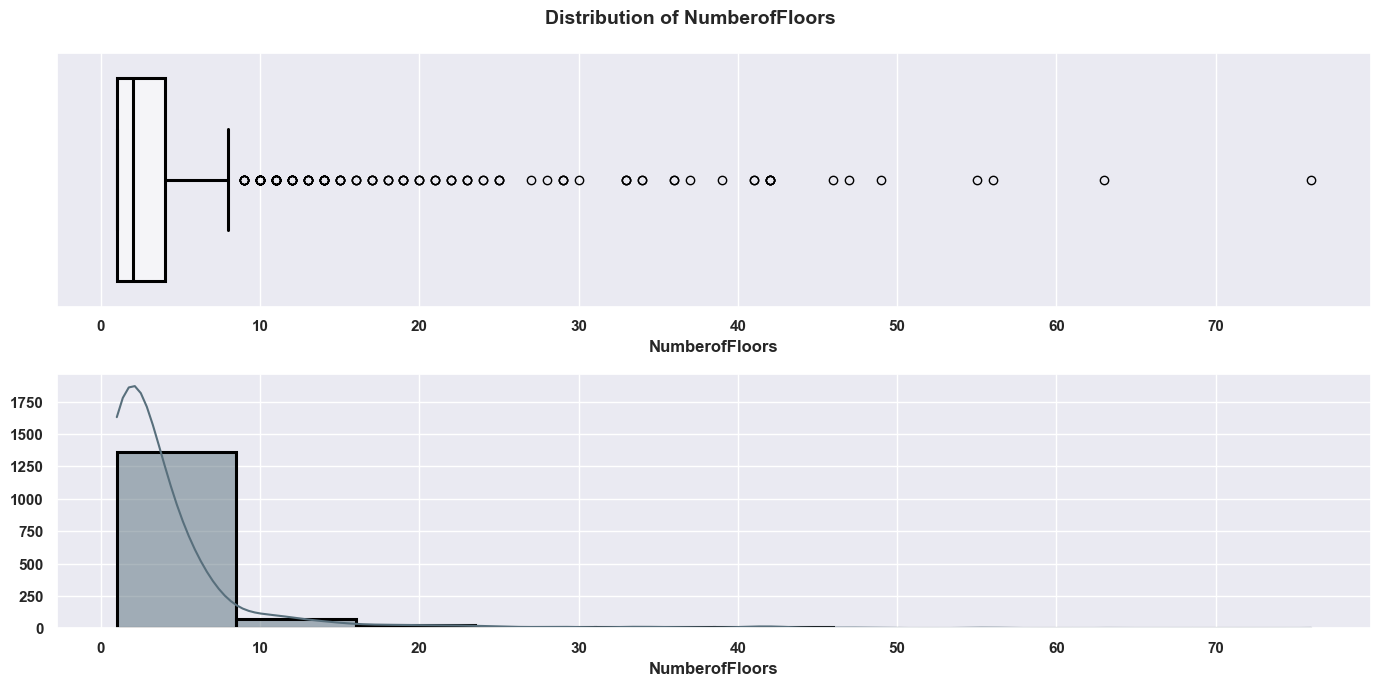

2026-02-16 00:37:53 | SUCCESS  | energy_sights.plots - Plot generation for the column NumberofFloors complete
2026-02-16 00:37:53.634 | SUCCESS  | energy_sights.plots:plot_distribution:51 - Plot generation for the column NumberofFloors complete


In [116]:
# Analyse de la distribution de cette colonne.
plot_distribution(df=df_compliant_filtered, col='NumberofFloors', bins=10)

In [117]:
# Visualisation interactive avec Plotly.
fig = px.histogram(data_frame=df_compliant_filtered,
                   x='NumberofFloors',
                   nbins=50,
                    opacity=.7,
                   marginal='box',
                   title='NumberofFloors Distribution')
fig.update_layout(bargap=.1)
fig.show()

## PropertyGFATotal Analysis

In [118]:
# Démarrage par les statistiques descriptives.
numeric_describe(df=df_compliant_filtered, col='PropertyGFATotal')

count     1.493000e+03
mean      1.215228e+05
std       3.095231e+05
min       1.128500e+04
25%       2.880800e+04
50%       4.800600e+04
75%       1.075720e+05
max       9.320156e+06
mode_1    2.592000e+04
mode_2    2.880000e+04
mode_3    3.600000e+04
Name: PropertyGFATotal, dtype: float64

In [119]:
# Analyse des valeurs uniques de PropertyGFATotal.
df_compliant_filtered['PropertyGFATotal'].nunique()

1420

In [120]:
df_compliant_filtered.sort_values(by='PropertyGFATotal', ascending=False, kind='quicksort')[['NumberofBuildings', 'NumberofFloors', 'YearBuilt']]

,NumberofBuildings,NumberofFloors,YearBuilt
3274,111.0,1,1900
1494,1.0,2,1939
559,1.0,76,1985
618,7.0,14,1994
292,1.0,56,1989
...,...,...,...
3373,1.0,1,1974
3365,1.0,1,1972
3362,1.0,1,2010
3361,1.0,1,2013


In [121]:
# Visualisation interactive de la distribution.
interactive_distribution(df=df_compliant_filtered, col='PropertyGFATotal')

### let's apply the logarithm function on the PropertyGFATotal to see the changes

In [122]:
df_compliant_filtered = logarithm(df=df_compliant_filtered, col='PropertyGFATotal')

2026-02-16 00:37:56 | INFO     | energy_sights.preprocessing - The logarithm function has been used on PropertyGFATotal with success.
2026-02-16 00:37:56.512 | INFO     | energy_sights.preprocessing:logarithm:86 - The logarithm function has been used on PropertyGFATotal with success.


In [123]:
# Visualisation de la distribution apres transformation.
interactive_distribution(df=df_compliant_filtered, col='PropertyGFATotalLog')

In [124]:
df_compliant_filtered.head(n=5)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,PropertyGFATotalLog
0,Hotel,1927,88434,0,Downtown,1.0,12,47.61220,-122.33799,7226362.5,249.98,0,11.390012
1,Hotel,1996,103566,15064,Downtown,1.0,11,47.61317,-122.33393,8387933.0,295.86,0,11.547964
2,Hotel,1969,956110,196718,Downtown,1.0,41,47.61393,-122.33810,72587024.0,2089.28,0,13.770628
3,Hotel,1926,61320,0,Downtown,1.0,10,47.61412,-122.33664,6794584.0,286.43,0,11.023861
4,Hotel,1980,175580,62000,Downtown,1.0,18,47.61375,-122.34047,14172606.0,505.01,0,12.075850


In [125]:
# Suppression de la colonne PropertyGFATotalLog créée uniquement pour l'analyse visuelle.
df_compliant_filtered = df_compliant_filtered.drop(axis=1, labels=['PropertyGFATotalLog'])

### Latitude and Longitude

In [126]:
df_compliant_filtered.filter(items=['Latitude', 'Longitude']).head()

,Latitude,Longitude
0,47.61220,-122.33799
1,47.61317,-122.33393
2,47.61393,-122.33810
3,47.61412,-122.33664
4,47.61375,-122.34047


In [127]:
numeric_describe(df=df_compliant_filtered, col='Longitude')

count    1493.000000
mean     -122.333442
std         0.023345
min      -122.411820
25%      -122.342870
50%      -122.333040
75%      -122.322640
max      -122.261800
mode     -122.298980
Name: Longitude, dtype: float64

In [128]:
numeric_describe(df=df_compliant_filtered, col='Latitude')

count    1493.000000
mean       47.616566
std         0.047058
min        47.509590
25%        47.587810
50%        47.612870
75%        47.649320
max        47.733870
mode       47.662460
Name: Latitude, dtype: float64

### With all the things I see on the internet about the boundaries of the city of Seattle, the data is pretty clean.

In [129]:
# Utilisation d'un nuage de points pour approfondir l'analyse.
fig = px.scatter(data_frame=df_compliant_filtered,
           x='Longitude',
           y='Latitude',
           opacity=.7,
            title='The City Seattle')
fig.show()

## The first target SiteEnergyUse(kBtu)

In [130]:
# Analyse statistique de la colonne cle du projet.
numeric_describe(df=df_compliant_filtered, col='SiteEnergyUse(kBtu)').head(n=10)

count     1.493000e+03
mean      8.860645e+06
std       3.176307e+07
min       5.713320e+04
25%       1.242312e+06
50%       2.701872e+06
75%       7.305474e+06
max       8.739237e+08
mode_1    5.713320e+04
mode_2    7.971180e+04
Name: SiteEnergyUse(kBtu), dtype: float64

In [131]:
# Analyse de la distribution des donnees.
interactive_distribution(df=df_compliant_filtered, col='SiteEnergyUse(kBtu)', n_bins=100_000)

In [132]:
max_consumption = df_compliant_filtered['SiteEnergyUse(kBtu)'].max()

In [133]:
max_consumption

np.float64(873923712.0)

In [134]:
# Identification du bâtiment présentant la consommation maximale.
df_compliant_filtered.loc[df_compliant_filtered['SiteEnergyUse(kBtu)'] == max_consumption]
# Observation: il s'agit de l'Université de Washington.

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex
3274,University,1900,9320156,0,Northeast,111.0,1,47.65644,-122.31041,873923712.0,11140.56,1


In [135]:
# Compte tenu de l'asymétrie de la distribution, application d'une normalisation avant entrainement.
df_compliant_filtered = logarithm(df=df_compliant_filtered, col='SiteEnergyUse(kBtu)')

2026-02-16 00:38:02 | INFO     | energy_sights.preprocessing - The logarithm function has been used on SiteEnergyUse(kBtu) with success.
2026-02-16 00:38:02.319 | INFO     | energy_sights.preprocessing:logarithm:86 - The logarithm function has been used on SiteEnergyUse(kBtu) with success.


In [136]:
# Verification de la nouvelle distribution de la cible.
interactive_distribution(df=df_compliant_filtered, col='SiteEnergyUse(kBtu)Log')

In [137]:
# La transformation logarithmique étant efficace, elle sera appliquée via TransformedTargetRegressor.

In [138]:
# Suppression de la colonne SiteEnergyUse(kBtu)Log.
df_compliant_filtered = df_compliant_filtered.drop(columns='SiteEnergyUse(kBtu)Log')

In [139]:
df_compliant_filtered.head()

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex
0,Hotel,1927,88434,0,Downtown,1.0,12,47.61220,-122.33799,7226362.5,249.98,0
1,Hotel,1996,103566,15064,Downtown,1.0,11,47.61317,-122.33393,8387933.0,295.86,0
2,Hotel,1969,956110,196718,Downtown,1.0,41,47.61393,-122.33810,72587024.0,2089.28,0
3,Hotel,1926,61320,0,Downtown,1.0,10,47.61412,-122.33664,6794584.0,286.43,0
4,Hotel,1980,175580,62000,Downtown,1.0,18,47.61375,-122.34047,14172606.0,505.01,0


## 2nd Target: TotalGHGEmissions

In [140]:
# Analyse des statistiques essentielles des colonnes.
numeric_describe(df=df_compliant_filtered, col='TotalGHGEmissions')

count     1493.000000
mean       193.334528
std        790.721214
min         -0.800000
25%         20.300000
50%         49.580000
75%        146.930000
max      16870.980000
mode         6.300000
Name: TotalGHGEmissions, dtype: float64

In [141]:
interactive_distribution(df=df_compliant_filtered, col='TotalGHGEmissions')

In [142]:
# Identification des lignes avec TotalGHGEmissions negatives.
df_compliant_filtered.query(expr="TotalGHGEmissions <= 0", inplace=False)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex
513,Supermarket / Grocery Store,2008,57176,0,Magnolia / Queen Anne,1.0,1,47.63718,-122.37734,1.252517e+07,0.0,0
3206,Small- and Mid-Sized Office,2013,52000,0,Central,1.0,6,47.61432,-122.31257,3.427261e+05,-0.8,0


In [143]:
# Suppression des valeurs incohérentes (nulles ou negatives) pour TotalGHGEmissions.
df_compliant_filtered = df_compliant_filtered.query(expr="TotalGHGEmissions > 0", inplace=False)

In [144]:
# Verification apres correction.
df_compliant_filtered[df_compliant_filtered['TotalGHGEmissions'] <= 0]
# Validation: la correction est effective.

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex


## Features Creation

In [145]:
df_compliant_filtered = engineer_features(df=df_compliant_filtered)

2026-02-16 00:38:08 | INFO     | energy_sights.features - Launching the features creation pipeline
2026-02-16 00:38:08.117 | INFO     | energy_sights.features:engineer_features:61 - Launching the features creation pipeline
2026-02-16 00:38:08 | INFO     | energy_sights.features - Binarization of the features
2026-02-16 00:38:08.125 | INFO     | energy_sights.features:create_binarization:13 - Binarization of the features
2026-02-16 00:38:08 | INFO     | energy_sights.features - Creation of the column based on the BuiltYear.
2026-02-16 00:38:08.143 | INFO     | energy_sights.features:create_date:25 - Creation of the column based on the BuiltYear.
2026-02-16 00:38:08 | SUCCESS  | energy_sights.features - New columns: 3
2026-02-16 00:38:08.214 | SUCCESS  | energy_sights.features:engineer_features:67 - New columns: 3


In [146]:
# Verification generale des donnees.
df_compliant_filtered.info(memory_usage='deep')

<class 'pandas.DataFrame'>
Index: 1491 entries, 0 to 3375
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PrimaryPropertyType  1491 non-null   str    
 1   YearBuilt            1491 non-null   int64  
 2   PropertyGFATotal     1491 non-null   int64  
 3   PropertyGFAParking   1491 non-null   int64  
 4   Neighborhood         1491 non-null   str    
 5   NumberofFloors       1491 non-null   int64  
 6   Latitude             1491 non-null   float64
 7   Longitude            1491 non-null   float64
 8   SiteEnergyUse(kBtu)  1491 non-null   float64
 9   TotalGHGEmissions    1491 non-null   float64
 10  IsComplex            1491 non-null   Int32  
 11  BuildingAge          1491 non-null   int64  
 12  AverageFloorArea     1491 non-null   float64
 13  DistToCenter         1491 non-null   float64
 14  ParkingRatio         1491 non-null   float64
dtypes: Int32(1), float64(7), int64(5), str(2)
memory usage

In [147]:
df_compliant_filtered.head(n=5)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,BuildingAge,AverageFloorArea,DistToCenter,ParkingRatio
0,Hotel,1927,88434,0,Downtown,12,47.61220,-122.33799,7226362.5,249.98,0,89,7369.500000,11742.615082,0.000000
1,Hotel,1996,103566,15064,Downtown,11,47.61317,-122.33393,8387933.0,295.86,0,20,9415.090909,11743.170496,0.145453
2,Hotel,1969,956110,196718,Downtown,41,47.61393,-122.33810,72587024.0,2089.28,0,47,23319.756098,11742.794402,0.205748
3,Hotel,1926,61320,0,Downtown,10,47.61412,-122.33664,6794584.0,286.43,0,90,6132.000000,11742.976556,0.000000
4,Hotel,1980,175580,62000,Downtown,18,47.61375,-122.34047,14172606.0,505.01,0,36,9754.444444,11742.512927,0.353115


In [148]:
# Analyse des variables textuelles et catégorielles.
df_compliant_filtered.select_dtypes(include='string')

,PrimaryPropertyType,Neighborhood
0,Hotel,Downtown
1,Hotel,Downtown
2,Hotel,Downtown
3,Hotel,Downtown
4,Hotel,Downtown
...,...,...
3370,Other,Delridge Neighborhoods
3372,Other,Downtown
3373,Other,Magnolia / Queen Anne
3374,Mixed Use Property,Greater Duwamish


In [149]:
# Verification de la granularité des colonnes catégorielles.
df_compliant_filtered.select_dtypes(include='string').nunique()

PrimaryPropertyType    16
Neighborhood           13
dtype: int64

In [150]:
df_compliant_filtered.head(n=5)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,BuildingAge,AverageFloorArea,DistToCenter,ParkingRatio
0,Hotel,1927,88434,0,Downtown,12,47.61220,-122.33799,7226362.5,249.98,0,89,7369.500000,11742.615082,0.000000
1,Hotel,1996,103566,15064,Downtown,11,47.61317,-122.33393,8387933.0,295.86,0,20,9415.090909,11743.170496,0.145453
2,Hotel,1969,956110,196718,Downtown,41,47.61393,-122.33810,72587024.0,2089.28,0,47,23319.756098,11742.794402,0.205748
3,Hotel,1926,61320,0,Downtown,10,47.61412,-122.33664,6794584.0,286.43,0,90,6132.000000,11742.976556,0.000000
4,Hotel,1980,175580,62000,Downtown,18,47.61375,-122.34047,14172606.0,505.01,0,36,9754.444444,11742.512927,0.353115


### Correlation


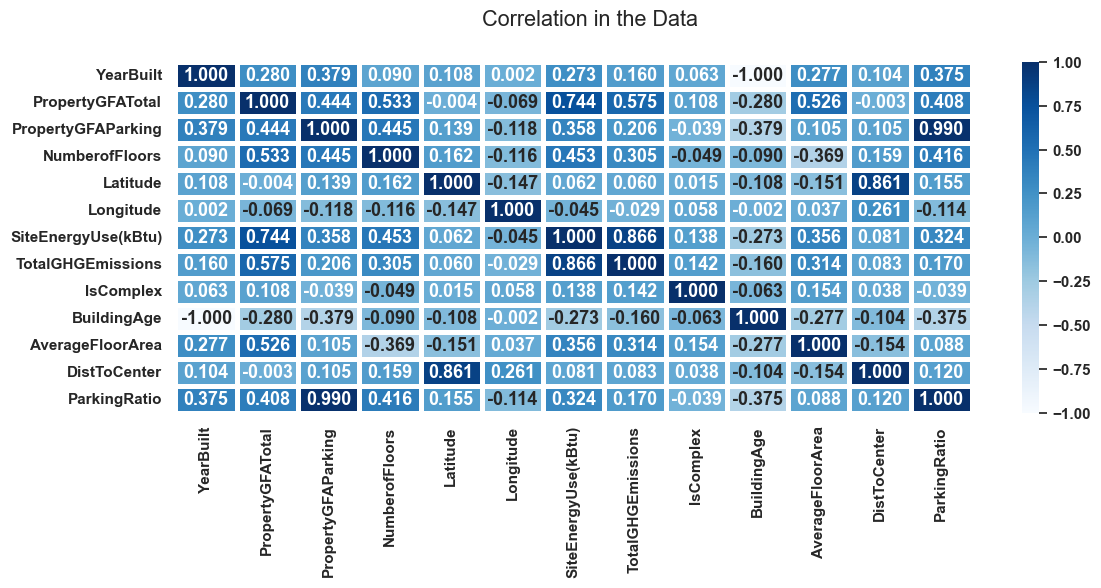

2026-02-16 00:38:13 | INFO     | energy_sights.plots - The heat_correlation is done: corr_shape (13, 13)
2026-02-16 00:38:13.792 | INFO     | energy_sights.plots:heat_correlation:92 - The heat_correlation is done: corr_shape (13, 13)


In [151]:
# Etude des correlations entre variables explicatives et cibles.
heat_correlation(df=df_compliant_filtered, num_only=True, method='spearman')

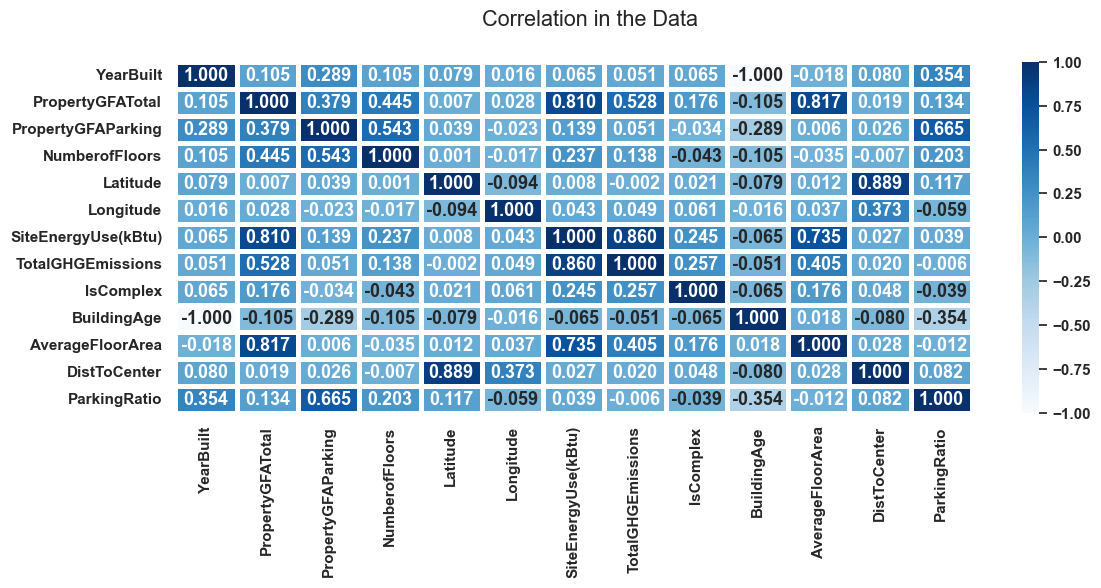

2026-02-16 00:38:15 | INFO     | energy_sights.plots - The heat_correlation is done: corr_shape (13, 13)
2026-02-16 00:38:15.726 | INFO     | energy_sights.plots:heat_correlation:92 - The heat_correlation is done: corr_shape (13, 13)


In [152]:
# Test complémentaire avec la methode de Pearson.
heat_correlation(df=df_compliant_filtered, num_only=True, method='pearson')

In [153]:
# Nettoyage des donnees pour réduire la colinéarité entre variables.
df_compliant_filtered = df_compliant_filtered.drop(columns=[
    'PropertyGFAParking',
    'YearBuilt'
])

## Data Export

In [154]:
# Verification finale des donnees avant export.
df_compliant_filtered.info(memory_usage='deep')

<class 'pandas.DataFrame'>
Index: 1491 entries, 0 to 3375
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PrimaryPropertyType  1491 non-null   str    
 1   PropertyGFATotal     1491 non-null   int64  
 2   Neighborhood         1491 non-null   str    
 3   NumberofFloors       1491 non-null   int64  
 4   Latitude             1491 non-null   float64
 5   Longitude            1491 non-null   float64
 6   SiteEnergyUse(kBtu)  1491 non-null   float64
 7   TotalGHGEmissions    1491 non-null   float64
 8   IsComplex            1491 non-null   Int32  
 9   BuildingAge          1491 non-null   int64  
 10  AverageFloorArea     1491 non-null   float64
 11  DistToCenter         1491 non-null   float64
 12  ParkingRatio         1491 non-null   float64
dtypes: Int32(1), float64(7), int64(3), str(2)
memory usage: 315.5 KB


In [155]:
processed_dir: Path = PROCESSED_DATA_DIR / 'processed_data.csv'

In [156]:
df_compliant_filtered.to_csv(path_or_buf=processed_dir, sep=',', index=False, decimal='.')

### now let's create two notebooks for the model training